# **Pratical 1**

**Load data and model training**

Train users: 200948, Movies: 84432
Test users:  200948, Movies: 84432
Iter 1: Train RMSE=0.8367, Test RMSE=0.8695, Loss=1079698.0868
Iter 2: Train RMSE=0.7486, Test RMSE=0.8140, Loss=913192.2680
Iter 3: Train RMSE=0.7228, Test RMSE=0.7906, Loss=867172.8647
Iter 4: Train RMSE=0.7131, Test RMSE=0.7815, Loss=849847.7487
Iter 5: Train RMSE=0.7085, Test RMSE=0.7772, Loss=841260.0467
Iter 6: Train RMSE=0.7058, Test RMSE=0.7749, Loss=835978.9789
Iter 7: Train RMSE=0.7040, Test RMSE=0.7733, Loss=832229.0460
Iter 8: Train RMSE=0.7027, Test RMSE=0.7722, Loss=829332.3332
Iter 9: Train RMSE=0.7017, Test RMSE=0.7713, Loss=827001.5448
Iter 10: Train RMSE=0.7009, Test RMSE=0.7706, Loss=825088.2878
Iter 11: Train RMSE=0.7002, Test RMSE=0.7701, Loss=823489.4539
Iter 12: Train RMSE=0.6997, Test RMSE=0.7697, Loss=822132.2557
Iter 13: Train RMSE=0.6993, Test RMSE=0.7694, Loss=820967.9103
Iter 14: Train RMSE=0.6989, Test RMSE=0.7692, Loss=819954.5836
Iter 15: Train RMSE=0.6987, Test RMSE=0.7690, Loss=81905

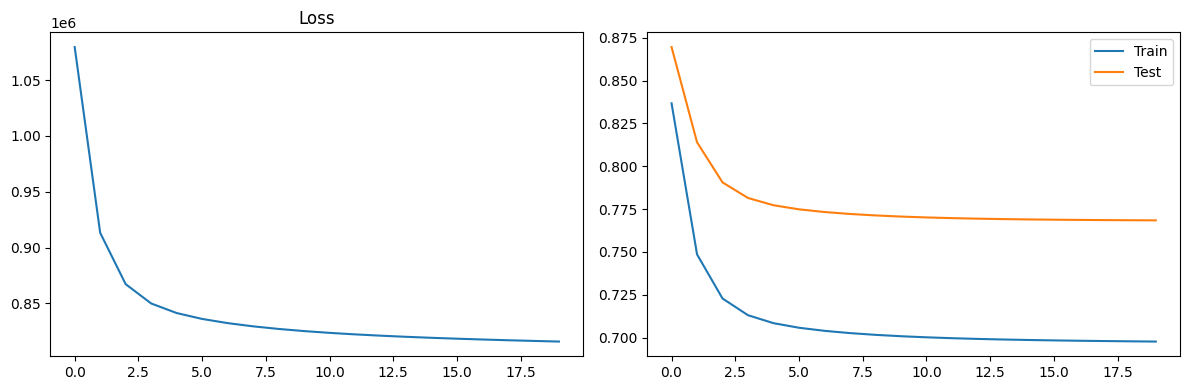

In [ ]:
from data.load_ratings import structure_data
from data.split import data_split
from data.features import load_features
from models.als_features import train_als_features
from prediction.dummy_user import build_dummy_rating_from_indices
from prediction.recommend import compute_dummy_user, predict_dummy_user
from visualization.loss_rmse_plots import loss_rmse


idx_to_movie, _, movieid_to_idx, _, data_by_movie, data_by_user = structure_data()
data_by_user_train, data_by_user_test, data_by_movie_train, data_by_movie_test = data_split(
    data_by_movie, data_by_user
)
item_features, features_having_items = load_features(data_by_movie, movieid_to_idx)

U, V, f, user_biases, item_biases, loss_hist, train_rmse_history, test_rmse_history = train_als_features(
    data_by_user_train, data_by_movie_train, data_by_user_test,
    item_features, features_having_items,
    lambda_val=0.1, gamma=0.04, tau=2.1, n_iters=20, verbose=True
)

loss_rmse(loss_hist, train_rmse_history, test_rmse_history,
          filename="pdf_reports/rmse_and_loss_full_features_model.pdf")



**Prediction**

In [ ]:
movie_indices = [33, 59, 13, 1819, 339, 596, 613, 46075, 67934, 63, 75, 674]
ratings = [5.0, 4.5, 5.0, 4.0, 5.0, 4.5,5.0, 4.5, 5.0, 4.0, 5.0, 4.5]

dummy_ratings, dummy_movie_idx, movie_id, movieid_to_title = build_dummy_rating_from_indices(
    movie_indices, ratings
)

print("Dummy ratings:", dummy_ratings)

dummy_user_factors, dummy_user_bias = compute_dummy_user(
    V, item_biases, dummy_ratings, K=15,
    lambda_val=0.1, tau=2.1, gamma_bias=0.04
)

print("Dummy user latent factors:", dummy_user_factors[:5], "...")
print("Dummy user bias:", dummy_user_bias)

predictions_full_bias, predictions_scaled_bias = predict_dummy_user(
    dummy_user_factors, V, item_biases, bias_scale=0.05
)

print("\n🎬 Top 10 Recommendations (bias complet)")
for item_idx, score in predictions_full_bias[:10]:
    movie_id = list(movieid_to_idx.keys())[list(movieid_to_idx.values()).index(item_idx)]
    title = movieid_to_title.get(movie_id, f"MovieIdx {item_idx}") if movie_id else f"MovieIdx {item_idx}"
    print(f"- {title:60s} | Score prédit : {score:.4f}")

print("\n🎬 Top 10 Recommendations (bias pondéré 0.05)")
for item_idx, score in predictions_scaled_bias[:10]:
    movie_id = list(movieid_to_idx.keys())[list(movieid_to_idx.values()).index(item_idx)]
    title = movieid_to_title.get(movie_id, f"MovieIdx {item_idx}") if movie_id else f"MovieIdx {item_idx}"
    print(f"- {title:60s} | Score prédit : {score:.4f}")


Dummy ratings: [(33, 5.0), (59, 4.5), (13, 5.0), (1819, 4.0), (339, 5.0), (596, 4.5), (613, 5.0), (46075, 4.5), (67934, 5.0), (63, 4.0), (75, 5.0), (674, 4.5)]
Dummy user latent factors: [ 0.11004218  0.55177736 -0.1411575   0.12939131  0.06285565] ...
Dummy user bias: 1.8597729

🎬 Top 10 Recommendations (bias complet)
- Star Wars: Episode IV - A New Hope (1977)                    | Score prédit : 6.7555
- Star Wars: Episode V - The Empire Strikes Back (1980)        | Score prédit : 6.4323
- Star Wars: Episode VI - Return of the Jedi (1983)            | Score prédit : 5.8670
- Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981) | Score prédit : 4.9973
- Pulp Fiction (1994)                                          | Score prédit : 4.8082
- Lord of the Rings: The Fellowship of the Ring, The (2001)    | Score prédit : 4.7613
- Lord of the Rings: The Return of the King, The (2003)        | Score prédit : 4.7332
- Lord of the Rings: The Two Towers, The (2002)     

**Calculation of already rated movie movie contribution**

In [ ]:
from explainer.contribution_items_passed import top_historical_contributions

item_idx = 1819 

# --- Calculate historiques contributions ---
contribs = top_historical_contributions(
    item_idx=item_idx,
    V=V,
    user_history=dummy_ratings, 
    lambda_val=0.1,
    tau=1.9
)

# --- Display top contributions ---
print(f"\n🔍 Top contributions historiques pour l'item {item_idx}:")
for j, c in contribs[:10]:  # top 10 contributions
    movie_id = list(movieid_to_idx.keys())[list(movieid_to_idx.values()).index(j)]
    title = movieid_to_title.get(movie_id, f"MovieIdx {j}")
    print(f"- {title:60s} | contribution = {c:.4f}")



🔍 Top contributions historiques pour l'item 1819:
- Lord of the Rings, The (1978)                                | contribution = 6.1649
- Apocalypse Now (1979)                                        | contribution = 0.7957
- Lord of the Rings: The Fellowship of the Ring, The (2001)    | contribution = 0.4860
- Lord of the Rings: The Two Towers, The (2002)                | contribution = 0.4082
- Lord of the Rings: The Return of the King, The (2003)        | contribution = 0.3525
- Clerks (1994)                                                | contribution = 0.3052
- J.R.R. Tolkien and the Birth Of "The Lord of the Rings" And "The Hobbit" (2013) | contribution = 0.0696
- Ran (1985)                                                   | contribution = -0.0248
- Casablanca (1942)                                            | contribution = -0.0415
- A Passage to Middle-earth: Making of 'Lord of the Rings' (2001) | contribution = -0.0795
